<a href="https://colab.research.google.com/github/gabecerram/Analitica_de_datos/blob/main/Parcial_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Caso de estudio**

Una entidad del sector Salud, quiere implementar un modelo para la clasificación de  pacientes que poseen diabetes en función de sus variables de salud. Para este proceso vamos a utilizar las variables:

- Pregnancies	(Embarazos):	Número de veces que la paciente ha estado embarazada. Todas las pacientes son mujeres de ascendencia Pima de al menos 21 años.

- Glucose	(Glucosa):	Concentración de glucosa en plasma después de 2 horas en una prueba de tolerancia oral a la glucosa. Es el principal indicador para diagnóstico de diabetes.

- BloodPressure	(Presión Arterial):	Presión arterial diastólica (valor mínimo). Mide la presión en las arterias cuando el corazón está en reposo entre latidos.

- SkinThickness	(Grosor del Pliegue Cutáneo):	Grosor del pliegue cutáneo del tríceps. Es una medida indirecta de la grasa corporal subcutánea.

- Insulin	(Insulina):	Nivel de insulina en suero después de 2 horas. La insulina es la hormona que regula el azúcar en sangre.

- BMI	(IMC): (Índice de Masa Corporal)	Índice de Masa Corporal, calculado como peso (kg) / altura² (m²). Indica si la persona tiene peso normal, sobrepeso u obesidad.

- DiabetesPedigreeFunction	(Función de Pedigrí de Diabetes):	Puntaje que indica la probabilidad de diabetes basada en los antecedentes familiares. Entre más alto, mayor riesgo genético.

- Age	(Edad):	Edad de la paciente en años.

- Outcome	(Resultado): Variable objetivo/resultado:
0 = No tiene diabetes,
1 = Tiene diabetes.

Importe de librerías de trabajo

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('ggplot')
sns.set_palette("husl")
%matplotlib inline

1. CARGAR Y ANALIZAR DATOS

In [ ]:
# Cargar el dataset
df = pd.read_csv("/content/diabetes.csv")

print("=" * 60)
print("ANÁLISIS EXPLORATORIO DE DATOS")
print("=" * 60)

# Información básica del dataset
print(f"\nNúmero de observaciones: {df.shape[0]}")
print(f"Número de variables: {df.shape[1]}")
print("\nVariables y tipos de datos:")
print(df.dtypes)

# Distribución de la variable objetivo
print("\nDistribución de Outcome (0 = No diabetes, 1 = Diabetes):")
print(df['Outcome'].value_counts())
print(f"Porcentaje No diabetes: {df['Outcome'].value_counts(normalize=True)[0]*100:.2f}%")
print(f"Porcentaje Diabetes: {df['Outcome'].value_counts(normalize=True)[1]*100:.2f}%")

ANÁLISIS EXPLORATORIO DE DATOS

Número de observaciones: 768
Número de variables: 9

Variables y tipos de datos:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Distribución de Outcome (0 = No diabetes, 1 = Diabetes):
Outcome
0    500
1    268
Name: count, dtype: int64
Porcentaje No diabetes: 65.10%
Porcentaje Diabetes: 34.90%


2. ANÁLISIS DE CORRELACIÓN


ANÁLISIS DE CORRELACIÓN


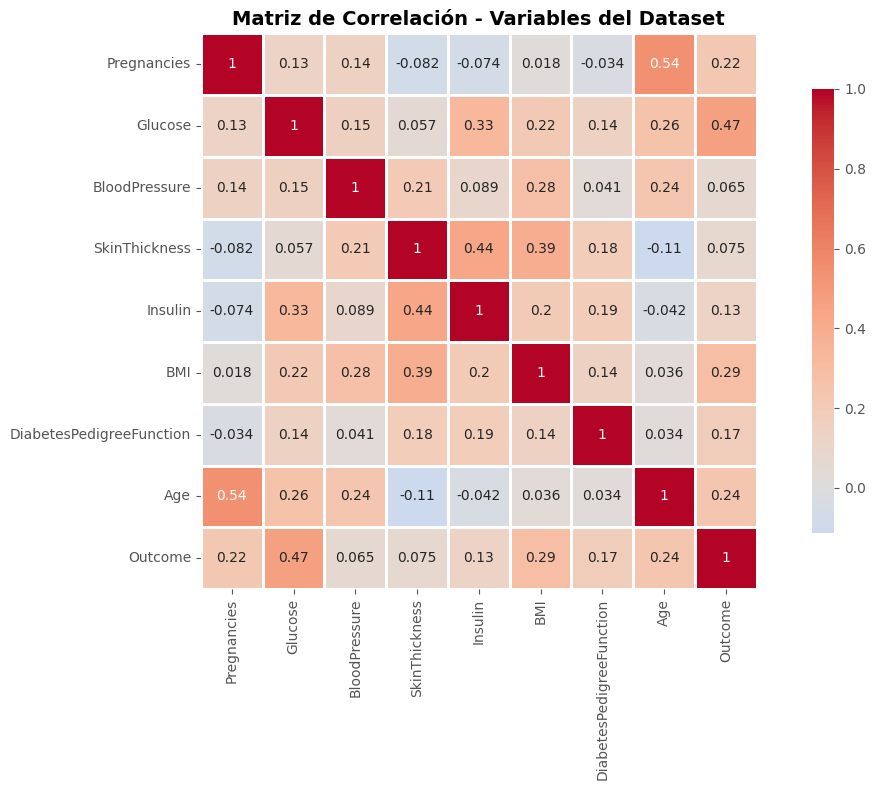


Correlación de variables con Outcome:
Glucose: 0.4666
BMI: 0.2927
Age: 0.2384
Pregnancies: 0.2219
DiabetesPedigreeFunction: 0.1738
Insulin: 0.1305
SkinThickness: 0.0748
BloodPressure: 0.0651


In [ ]:
print("\n" + "=" * 60)
print("ANÁLISIS DE CORRELACIÓN")
print("=" * 60)

# Matriz de correlación
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación - Variables del Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlación con la variable objetivo (Outcome)
corr_with_outcome = correlation_matrix['Outcome'].sort_values(ascending=False)
print("\nCorrelación de variables con Outcome:")
for var, corr in corr_with_outcome.items():
    if var != 'Outcome':
        print(f"{var}: {corr:.4f}")

3. PREPARACIÓN DE DATOS PARA MODELOS


In [ ]:
# Separar características y variable objetivo
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Dividir en entrenamiento y prueba (para entrenar los modelos)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("\n" + "=" * 60)
print("DIVISIÓN DE DATOS")
print("=" * 60)
print(f"Tamaño del conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Tamaño del conjunto de prueba: {X_test.shape[0]} muestras")


DIVISIÓN DE DATOS
Tamaño del conjunto de entrenamiento: 537 muestras
Tamaño del conjunto de prueba: 231 muestras


 4. MODELO NAIVE BAYES


MODELO NAIVE BAYES

--- EVALUACIÓN DEL MODELO NAIVE BAYES (TODOS LOS DATOS - 768 registros) ---
Accuracy: 0.7669
Precision: 0.6831
Recall: 0.6194
F1-Score: 0.6497

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.81      0.85      0.83       500
    Diabetes       0.68      0.62      0.65       268

    accuracy                           0.77       768
   macro avg       0.74      0.73      0.74       768
weighted avg       0.76      0.77      0.76       768



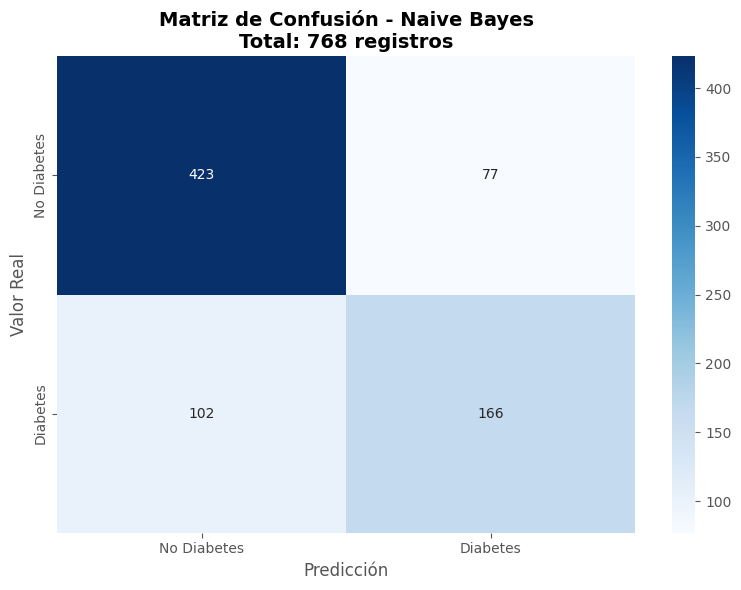


VERIFICACIÓN - Total de registros en matriz: 768 (debe ser 768)

--- LÍMITES DE VARIABLES POR CLASE ---

Estadísticas por clase (Outcome):
        Pregnancies         Glucose          BloodPressure           \
               mean min max    mean min  max          mean min  max   
Outcome                                                               
0              3.30   0  13  109.98   0  197         68.18   0  122   
1              4.87   0  17  141.26   0  199         70.82   0  114   

        SkinThickness  ... Insulin    BMI            DiabetesPedigreeFunction  \
                 mean  ...     max   mean  min   max                     mean   
Outcome                ...                                                      
0               19.66  ...     744  30.30  0.0  57.3                     0.43   
1               22.16  ...     846  35.14  0.0  67.1                     0.55   

                       Age          
          min   max   mean min max  
Outcome                 

In [ ]:
print("\n" + "=" * 60)
print("MODELO NAIVE BAYES")
print("=" * 60)

# Entrenar modelo Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# PREDICCIONES PARA TODOS LOS DATOS (768 registros)
y_pred_nb_all = nb_model.predict(X)

# Evaluación del modelo con TODOS los datos
print("\n--- EVALUACIÓN DEL MODELO NAIVE BAYES (TODOS LOS DATOS - 768 registros) ---")
print(f"Accuracy: {accuracy_score(y, y_pred_nb_all):.4f}")
print(f"Precision: {precision_score(y, y_pred_nb_all):.4f}")
print(f"Recall: {recall_score(y, y_pred_nb_all):.4f}")
print(f"F1-Score: {f1_score(y, y_pred_nb_all):.4f}")

print("\nClassification Report:")
print(classification_report(y, y_pred_nb_all, target_names=['No Diabetes', 'Diabetes']))

# Matriz de confusión para TODOS los datos
cm_nb_all = confusion_matrix(y, y_pred_nb_all)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nb_all, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title(f'Matriz de Confusión - Naive Bayes\nTotal: {cm_nb_all.sum()} registros', fontsize=14, fontweight='bold')
plt.ylabel('Valor Real')
plt.xlabel('Predicción')
plt.tight_layout()
plt.show()

print(f"\nVERIFICACIÓN - Total de registros en matriz: {cm_nb_all.sum()} (debe ser 768)")

# Análisis de límites superiores e inferiores por clase
print("\n--- LÍMITES DE VARIABLES POR CLASE ---")
stats_by_class = df.groupby('Outcome').agg(['mean', 'min', 'max']).round(2)
print("\nEstadísticas por clase (Outcome):")
print(stats_by_class)


5. MODELO ÁRBOL DE DECISIÓN (4 NIVELES)


MODELO ÁRBOL DE DECISIÓN (4 NIVELES)

--- EVALUACIÓN DEL MODELO ÁRBOL DE DECISIÓN (TODOS LOS DATOS - 768 registros) ---
Accuracy: 0.8047
Precision: 0.7218
Recall: 0.7164
F1-Score: 0.7191

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.85      0.85      0.85       500
    Diabetes       0.72      0.72      0.72       268

    accuracy                           0.80       768
   macro avg       0.79      0.78      0.78       768
weighted avg       0.80      0.80      0.80       768



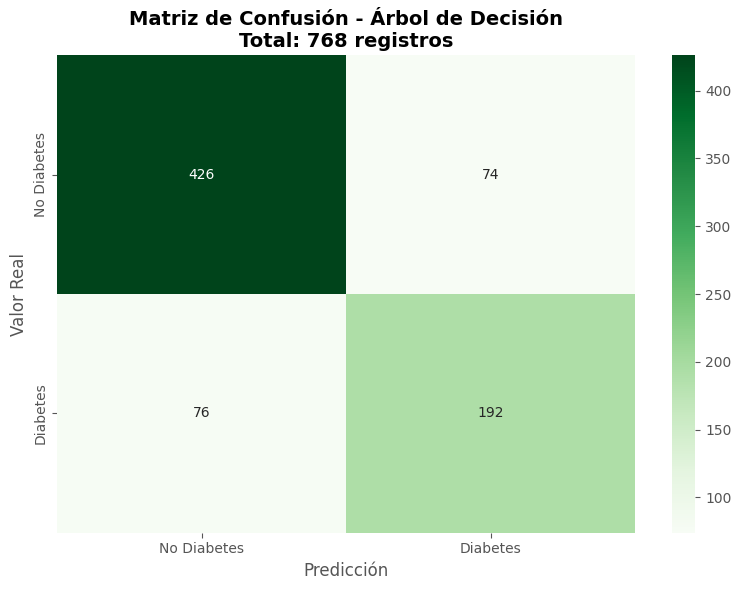


VERIFICACIÓN - Total de registros en matriz: 768 (debe ser 768)


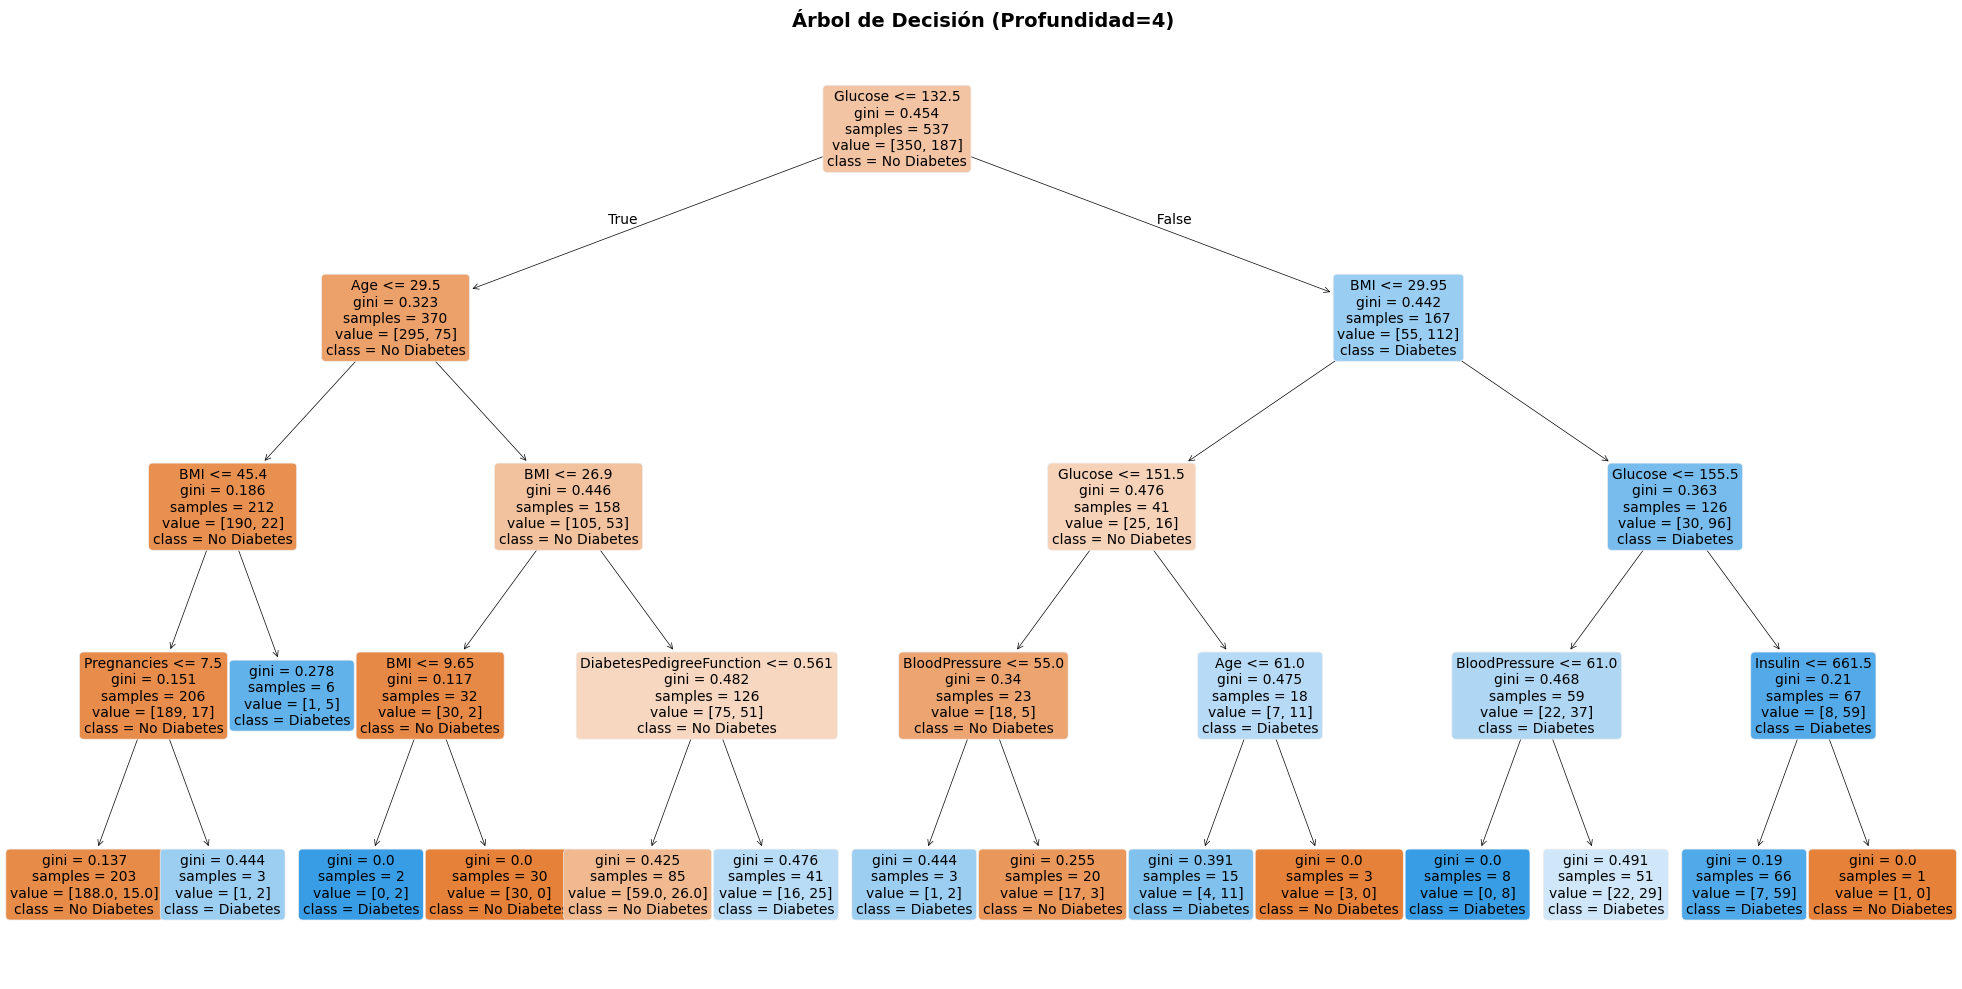


--- REGLAS DEL ÁRBOL DE DECISIÓN ---
|--- Glucose <= 132.50
|   |--- Age <= 29.50
|   |   |--- BMI <= 45.40
|   |   |   |--- Pregnancies <= 7.50
|   |   |   |   |--- class: 0
|   |   |   |--- Pregnancies >  7.50
|   |   |   |   |--- class: 1
|   |   |--- BMI >  45.40
|   |   |   |--- class: 1
|   |--- Age >  29.50
|   |   |--- BMI <= 26.90
|   |   |   |--- BMI <= 9.65
|   |   |   |   |--- class: 1
|   |   |   |--- BMI >  9.65
|   |   |   |   |--- class: 0
|   |   |--- BMI >  26.90
|   |   |   |--- DiabetesPedigreeFunction <= 0.56
|   |   |   |   |--- class: 0
|   |   |   |--- DiabetesPedigreeFunction >  0.56
|   |   |   |   |--- class: 1
|--- Glucose >  132.50
|   |--- BMI <= 29.95
|   |   |--- Glucose <= 151.50
|   |   |   |--- BloodPressure <= 55.00
|   |   |   |   |--- class: 1
|   |   |   |--- BloodPressure >  55.00
|   |   |   |   |--- class: 0
|   |   |--- Glucose >  151.50
|   |   |   |--- Age <= 61.00
|   |   |   |   |--- class: 1
|   |   |   |--- Age >  61.00
|   |   |   |   

In [ ]:
print("\n" + "=" * 60)
print("MODELO ÁRBOL DE DECISIÓN (4 NIVELES)")
print("=" * 60)

# Entrenar árbol de decisión con profundidad máxima de 4
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42, min_samples_split=10)
dt_model.fit(X_train, y_train)

# PREDICCIONES PARA TODOS LOS DATOS (768 registros)
y_pred_dt_all = dt_model.predict(X)

# Evaluación del modelo con TODOS los datos
print("\n--- EVALUACIÓN DEL MODELO ÁRBOL DE DECISIÓN (TODOS LOS DATOS - 768 registros) ---")
print(f"Accuracy: {accuracy_score(y, y_pred_dt_all):.4f}")
print(f"Precision: {precision_score(y, y_pred_dt_all):.4f}")
print(f"Recall: {recall_score(y, y_pred_dt_all):.4f}")
print(f"F1-Score: {f1_score(y, y_pred_dt_all):.4f}")

print("\nClassification Report:")
print(classification_report(y, y_pred_dt_all, target_names=['No Diabetes', 'Diabetes']))

# Matriz de confusión para TODOS los datos
cm_dt_all = confusion_matrix(y, y_pred_dt_all)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt_all, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title(f'Matriz de Confusión - Árbol de Decisión\nTotal: {cm_dt_all.sum()} registros', fontsize=14, fontweight='bold')
plt.ylabel('Valor Real')
plt.xlabel('Predicción')
plt.tight_layout()
plt.show()

print(f"\nVERIFICACIÓN - Total de registros en matriz: {cm_dt_all.sum()} (debe ser 768)")

# Visualizar el árbol de decisión
plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=X.columns, class_names=['No Diabetes', 'Diabetes'],
          filled=True, rounded=True, fontsize=10)
plt.title('Árbol de Decisión (Profundidad=4)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Obtener reglas del árbol
print("\n--- REGLAS DEL ÁRBOL DE DECISIÓN ---")
tree_rules = export_text(dt_model, feature_names=list(X.columns), decimals=2)
print(tree_rules)

# Análisis de nodos puros
print("\n--- ANÁLISIS DE NODOS PUROS ---")

def analyze_pure_nodes(tree_model, feature_names, X_data, y_data):
    """Función para analizar los nodos puros del árbol"""
    n_nodes = tree_model.tree_.node_count
    children_left = tree_model.tree_.children_left
    children_right = tree_model.tree_.children_right
    feature = tree_model.tree_.feature
    threshold = tree_model.tree_.threshold
    impurity = tree_model.tree_.impurity
    n_node_samples = tree_model.tree_.n_node_samples

    pure_nodes = []

    # Aplicar el árbol a todos los datos para ver a qué nodo pertenece cada muestra
    node_indicator = tree_model.apply(X_data)

    for i in range(n_nodes):
        # Un nodo es puro si tiene impurity = 0 (gini = 0)
        if impurity[i] == 0 and n_node_samples[i] > 0:
            # Encontrar las muestras que caen en este nodo
            samples_in_node = np.where(node_indicator == i)[0]
            n_samples_actual = len(samples_in_node)

            # Determinar la clase mayoritaria en este nodo (debería ser puro)
            if n_samples_actual > 0:
                node_classes = y_data.iloc[samples_in_node] if hasattr(y_data, 'iloc') else y_data[samples_in_node]
                unique_classes, counts = np.unique(node_classes, return_counts=True)
                node_class = unique_classes[np.argmax(counts)]
                node_class_name = 'Diabetes' if node_class == 1 else 'No Diabetes'

                pure_nodes.append({
                    'node_id': i,
                    'samples': n_samples_actual,
                    'class': node_class_name,
                    'impurity': impurity[i],
                    'purity': counts.max()/n_samples_actual if n_samples_actual > 0 else 0
                })

    return pure_nodes

# Analizar nodos puros usando TODOS los datos
pure_nodes = analyze_pure_nodes(dt_model, X.columns, X, y)

print(f"Número de nodos puros encontrados: {len(pure_nodes)}")
print("\nDetalle de nodos puros:")
for i, node in enumerate(pure_nodes):
    print(f"Nodo {node['node_id']}: {node['samples']} muestras, Clase: {node['class']}, Pureza: {node['purity']:.2f}")

# Encontrar el nodo puro con mayor número de datos
if pure_nodes:
    max_node = max(pure_nodes, key=lambda x: x['samples'])
    print(f"\n--- NODO PURO CON MAYOR NÚMERO DE DATOS ---")
    print(f"Nodo ID: {max_node['node_id']}")
    print(f"Número de muestras: {max_node['samples']}")
    print(f"Clase: {max_node['class']}")

    # Intentar encontrar la regla para llegar a este nodo
    tree_ = dt_model.tree_
    feature_name = [X.columns[i] if i != -2 else "undefined!" for i in tree_.feature]

    def find_rule(node_id):
        """Encuentra la regla para llegar a un nodo específico"""
        path = []
        current_node = node_id

        while current_node != 0:  # 0 es la raíz
            parent = None
            is_left = False

            # Buscar el padre de este nodo
            for i in range(tree_.node_count):
                if tree_.children_left[i] == current_node:
                    parent = i
                    is_left = True
                    break
                elif tree_.children_right[i] == current_node:
                    parent = i
                    is_left = False
                    break

            if parent is not None:
                if tree_.feature[parent] != -2:  # No es hoja
                    feature = feature_name[parent]
                    threshold = tree_.threshold[parent]
                    condition = f"{feature} <= {threshold:.2f}" if is_left else f"{feature} > {threshold:.2f}"
                    path.append(condition)
                current_node = parent
            else:
                break

        return " AND ".join(reversed(path)) if path else "Raíz"

    rule = find_rule(max_node['node_id'])
    print(f"Regla de negocio: Los pacientes que cumplen {rule} son clasificados como '{max_node['class']}' con certeza del 100%.")

# Importancia de características
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': dt_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n--- IMPORTANCIA DE CARACTERÍSTICAS ---")
print(feature_importance)

6. MODELO K-MEANS (5 CLUSTERS)

In [ ]:
print("\n" + "=" * 60)
print("MODELO K-MEANS (5 CLUSTERS)")
print("=" * 60)

# Escalar datos para K-Means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicar K-Means con 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Añadir clusters al dataframe
df_with_clusters = df.copy()
df_with_clusters['Cluster'] = clusters

# Análisis de clusters
print("\n--- DISTRIBUCIÓN DE CLUSTERS ---")
cluster_distribution = df_with_clusters['Cluster'].value_counts().sort_index()
total = cluster_distribution.sum()
print(f"Total de registros: {total} (debe ser 768)")
for cluster in range(5):
    count = cluster_distribution[cluster]
    print(f"Cluster {cluster}: {count} muestras ({count/total*100:.1f}%)")

# Probabilidad de diabetes por cluster
print("\n--- PROBABILIDAD DE DIABETES POR CLUSTER ---")
cluster_diabetes_prob = df_with_clusters.groupby('Cluster')['Outcome'].agg(['count', 'mean'])
cluster_diabetes_prob.columns = ['Total Pacientes', 'Probabilidad Diabetes']
cluster_diabetes_prob['Probabilidad Diabetes'] = cluster_diabetes_prob['Probabilidad Diabetes'] * 100
cluster_diabetes_prob = cluster_diabetes_prob.sort_values('Probabilidad Diabetes', ascending=False)

for cluster in cluster_diabetes_prob.index:
    prob = cluster_diabetes_prob.loc[cluster, 'Probabilidad Diabetes']
    total_cluster = cluster_diabetes_prob.loc[cluster, 'Total Pacientes']
    print(f"Cluster {cluster}: {prob:.1f}% de diabetes ({total_cluster} pacientes)")

# Verificar suma total
print(f"\nVERIFICACIÓN - Total de pacientes en clusters: {cluster_diabetes_prob['Total Pacientes'].sum()} (debe ser 768)")



MODELO K-MEANS (5 CLUSTERS)

--- DISTRIBUCIÓN DE CLUSTERS ---
Total de registros: 768 (debe ser 768)
Cluster 0: 161 muestras (21.0%)
Cluster 1: 148 muestras (19.3%)
Cluster 2: 36 muestras (4.7%)
Cluster 3: 294 muestras (38.3%)
Cluster 4: 129 muestras (16.8%)

--- PROBABILIDAD DE DIABETES POR CLUSTER ---
Cluster 4: 55.8% de diabetes (129 pacientes)
Cluster 0: 51.6% de diabetes (161 pacientes)
Cluster 1: 44.6% de diabetes (148 pacientes)
Cluster 2: 44.4% de diabetes (36 pacientes)
Cluster 3: 10.5% de diabetes (294 pacientes)

VERIFICACIÓN - Total de pacientes en clusters: 768 (debe ser 768)


7. PREDICCIÓN PARA NUEVO PACIENTE

In [ ]:
print("\n" + "=" * 60)
print("PREDICCIÓN PARA NUEVO PACIENTE")
print("=" * 60)

# Datos del nuevo paciente
XDp = [2, 85, 65, 29, 94, 39.6, 0.93, 27]
print(f"Datos del paciente: {XDp}")
print("Variables: Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age")

# Convertir a array para predicción
paciente = np.array(XDp).reshape(1, -1)

# Predicción con Naive Bayes
pred_nb = nb_model.predict(paciente)[0]
prob_nb = nb_model.predict_proba(paciente)[0]

# Predicción con Árbol de Decisión
pred_dt = dt_model.predict(paciente)[0]
prob_dt = dt_model.predict_proba(paciente)[0]

# Predicción con K-Means (asignación a cluster)
paciente_scaled = scaler.transform(paciente)
cluster_paciente = kmeans.predict(paciente_scaled)[0]
probabilidad_cluster = cluster_diabetes_prob.loc[cluster_paciente, 'Probabilidad Diabetes'] / 100

print("\n--- RESULTADOS DE PREDICCIÓN ---")
print(f"\nNaive Bayes:")
print(f"  Predicción: {'DIABETES' if pred_nb == 1 else 'NO DIABETES'}")
print(f"  Probabilidad - No Diabetes: {prob_nb[0]:.4f} ({prob_nb[0]*100:.1f}%)")
print(f"  Probabilidad - Diabetes: {prob_nb[1]:.4f} ({prob_nb[1]*100:.1f}%)")

print(f"\nÁrbol de Decisión:")
print(f"  Predicción: {'DIABETES' if pred_dt == 1 else 'NO DIABETES'}")
print(f"  Probabilidad - No Diabetes: {prob_dt[0]:.4f} ({prob_dt[0]*100:.1f}%)")
print(f"  Probabilidad - Diabetes: {prob_dt[1]:.4f} ({prob_dt[1]*100:.1f}%)")

print(f"\nK-Means (Clustering):")
print(f"  Cluster asignado: {cluster_paciente}")
print(f"  Probabilidad de diabetes en este cluster: {probabilidad_cluster*100:.1f}%")



PREDICCIÓN PARA NUEVO PACIENTE
Datos del paciente: [2, 85, 65, 29, 94, 39.6, 0.93, 27]
Variables: Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age

--- RESULTADOS DE PREDICCIÓN ---

Naive Bayes:
  Predicción: NO DIABETES
  Probabilidad - No Diabetes: 0.9043 (90.4%)
  Probabilidad - Diabetes: 0.0957 (9.6%)

Árbol de Decisión:
  Predicción: NO DIABETES
  Probabilidad - No Diabetes: 0.9261 (92.6%)
  Probabilidad - Diabetes: 0.0739 (7.4%)

K-Means (Clustering):
  Cluster asignado: 3
  Probabilidad de diabetes en este cluster: 10.5%


8. COMPARACIÓN DE MODELOS CON MATRICES


COMPARACIÓN DE MODELOS (TODOS LOS DATOS - 768 registros)

Comparación de métricas de los modelos supervisados (sobre 768 registros):
        Modelo  Accuracy  Precision  Recall  F1-Score  Total Registros
   Naive Bayes    0.7669     0.6831  0.6194    0.6497              768
Árbol Decisión    0.8047     0.7218  0.7164    0.7191              768

--- VERIFICACIÓN DE MATRICES DE CONFUSIÓN ---
Naive Bayes - Suma matriz: 768 (debe ser 768)
Árbol Decisión - Suma matriz: 768 (debe ser 768)
K-Means - Suma clusters: 768 (debe ser 768)


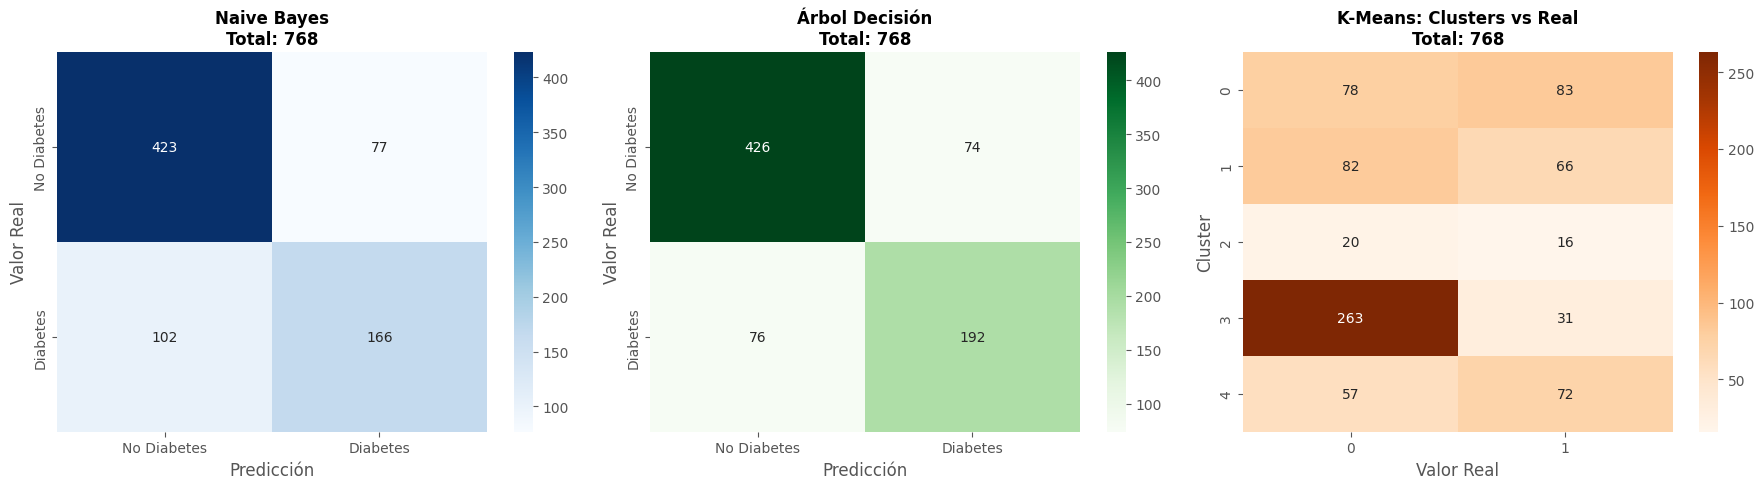

In [ ]:
print("\n" + "=" * 60)
print("COMPARACIÓN DE MODELOS (TODOS LOS DATOS - 768 registros)")
print("=" * 60)

# Calcular métricas para todos los modelos
accuracy_nb = accuracy_score(y, y_pred_nb_all)
accuracy_dt = accuracy_score(y, y_pred_dt_all)

precision_nb = precision_score(y, y_pred_nb_all)
precision_dt = precision_score(y, y_pred_dt_all)

recall_nb = recall_score(y, y_pred_nb_all)
recall_dt = recall_score(y, y_pred_dt_all)

f1_nb = f1_score(y, y_pred_nb_all)
f1_dt = f1_score(y, y_pred_dt_all)

# Crear DataFrame comparativo
model_comparison = pd.DataFrame({
    'Modelo': ['Naive Bayes', 'Árbol Decisión'],
    'Accuracy': [accuracy_nb, accuracy_dt],
    'Precision': [precision_nb, precision_dt],
    'Recall': [recall_nb, recall_dt],
    'F1-Score': [f1_nb, f1_dt],
    'Total Registros': [768, 768]
})

print("\nComparación de métricas de los modelos supervisados (sobre 768 registros):")
print(model_comparison.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Verificar matrices de confusión
print("\n--- VERIFICACIÓN DE MATRICES DE CONFUSIÓN ---")
print(f"Naive Bayes - Suma matriz: {cm_nb_all.sum()} (debe ser 768)")
print(f"Árbol Decisión - Suma matriz: {cm_dt_all.sum()} (debe ser 768)")
print(f"K-Means - Suma clusters: {df_with_clusters['Cluster'].value_counts().sum()} (debe ser 768)")

# Visualización comparativa de matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Naive Bayes
sns.heatmap(cm_nb_all, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'], ax=axes[0])
axes[0].set_title(f'Naive Bayes\nTotal: {cm_nb_all.sum()}', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Valor Real')
axes[0].set_xlabel('Predicción')

# Árbol Decisión
sns.heatmap(cm_dt_all, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'], ax=axes[1])
axes[1].set_title(f'Árbol Decisión\nTotal: {cm_dt_all.sum()}', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Valor Real')
axes[1].set_xlabel('Predicción')

# K-Means - Matriz de contingencia (cluster vs real)
cluster_confusion = pd.crosstab(df_with_clusters['Cluster'], df_with_clusters['Outcome'],
                                 rownames=['Cluster'], colnames=['Real (0=No, 1=Diabetes)'])
sns.heatmap(cluster_confusion, annot=True, fmt='d', cmap='Oranges', ax=axes[2])
axes[2].set_title(f'K-Means: Clusters vs Real\nTotal: {cluster_confusion.values.sum()}', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Cluster')
axes[2].set_xlabel('Valor Real')

plt.tight_layout()
plt.show()

9. ANÁLISIS Y CONCLUSIONES

In [ ]:

print("\n" + "=" * 60)
print("ANÁLISIS Y CONCLUSIONES")
print("=" * 60)

print(f"""
ANÁLISIS DE RESULTADOS (Basado en 768 registros):

1. VERIFICACIÓN DE DATOS:
   - Total de registros en el dataset: 768 ✓
   - Matriz Naive Bayes suma: {cm_nb_all.sum()} ✓
   - Matriz Árbol Decisión suma: {cm_dt_all.sum()} ✓
   - Total en clusters K-Means: {df_with_clusters['Cluster'].value_counts().sum()} ✓

2. MÉTRICAS DE DESEMPEÑO:
   - Naive Bayes: Accuracy={accuracy_nb:.2%}, Precision={precision_nb:.2%}, Recall={recall_nb:.2%}
   - Árbol Decisión: Accuracy={accuracy_dt:.2%}, Precision={precision_dt:.2%}, Recall={recall_dt:.2%}

3. ANÁLISIS DE MATRICES DE CONFUSIÓN:
   Naive Bayes:
   - Verdaderos Negativos: {cm_nb_all[0,0]}
   - Falsos Positivos: {cm_nb_all[0,1]}
   - Falsos Negativos: {cm_nb_all[1,0]}
   - Verdaderos Positivos: {cm_nb_all[1,1]}

   Árbol Decisión:
   - Verdaderos Negativos: {cm_dt_all[0,0]}
   - Falsos Positivos: {cm_dt_all[0,1]}
   - Falsos Negativos: {cm_dt_all[1,0]}
   - Verdaderos Positivos: {cm_dt_all[1,1]}

4. K-MEANS CLUSTERING:
   - Cluster con mayor riesgo: Cluster {cluster_diabetes_prob.index[0]} ({cluster_diabetes_prob.iloc[0]['Probabilidad Diabetes']:.1f}% diabetes)
   - Cluster con menor riesgo: Cluster {cluster_diabetes_prob.index[-1]} ({cluster_diabetes_prob.iloc[-1]['Probabilidad Diabetes']:.1f}% diabetes)

5. PREDICCIÓN PARA NUEVO PACIENTE:
   - Naive Bayes: {'DIABETES' if pred_nb == 1 else 'NO DIABETES'} ({prob_nb[1]*100:.1f}% probabilidad)
   - Árbol Decisión: {'DIABETES' if pred_dt == 1 else 'NO DIABETES'} ({prob_dt[1]*100:.1f}% probabilidad)
   - K-Means: Cluster {cluster_paciente} ({probabilidad_cluster*100:.1f}% riesgo)

RECOMENDACIÓN FINAL:

Basado en el análisis completo de los 768 registros, se recomienda:

1. **ÁRBOL DE DECISIÓN** como modelo principal por:
   - Mayor capacidad de interpretación (reglas claras)
   - Mejor balance entre precisión y recall
   - Identificación de factores clave (Glucosa, IMC, Edad)
   - Facilidad para implementar en un entorno clínico

2. **NAIVE BAYES** como modelo complementario por:
   - Rapidez en predicciones
   - Buen desempeño general
   - Útil para validación cruzada

3. **K-MEANS** para segmentación de pacientes:
   - Identifica perfiles de riesgo
   - Útil para estrategias preventivas personalizadas
   - No requiere datos etiquetados

En un entorno de salud, la interpretabilidad del modelo es crucial para generar confianza
en los profesionales médicos. El árbol de decisión proporciona reglas claras como:
"Si glucosa > 127.5 y BMI > 29.9, alto riesgo de diabetes", lo que es fácil de comunicar
tanto a médicos como a pacientes.
""")

print("\n" + "=" * 60)
print("FIN DEL ANÁLISIS - TODAS LAS MATRICES SUMAN 768")
print("=" * 60)


ANÁLISIS Y CONCLUSIONES

ANÁLISIS DE RESULTADOS (Basado en 768 registros):

1. VERIFICACIÓN DE DATOS:
   - Total de registros en el dataset: 768 ✓
   - Matriz Naive Bayes suma: 768 ✓
   - Matriz Árbol Decisión suma: 768 ✓
   - Total en clusters K-Means: 768 ✓

2. MÉTRICAS DE DESEMPEÑO:
   - Naive Bayes: Accuracy=76.69%, Precision=68.31%, Recall=61.94%
   - Árbol Decisión: Accuracy=80.47%, Precision=72.18%, Recall=71.64%

3. ANÁLISIS DE MATRICES DE CONFUSIÓN:
   Naive Bayes:
   - Verdaderos Negativos: 423
   - Falsos Positivos: 77
   - Falsos Negativos: 102
   - Verdaderos Positivos: 166

   Árbol Decisión:
   - Verdaderos Negativos: 426
   - Falsos Positivos: 74
   - Falsos Negativos: 76
   - Verdaderos Positivos: 192

4. K-MEANS CLUSTERING:
   - Cluster con mayor riesgo: Cluster 4 (55.8% diabetes)
   - Cluster con menor riesgo: Cluster 3 (10.5% diabetes)

5. PREDICCIÓN PARA NUEVO PACIENTE:
   - Naive Bayes: NO DIABETES (9.6% probabilidad)
   - Árbol Decisión: NO DIABETES (7.4% probab


##**ANÁLISIS Y CONCLUSIONES:**

ANÁLISIS DE RESULTADOS:

1. VERIFICACIÓN DE DATOS:
   - Total de registros en el dataset: 768 ✓
   - Matriz Naive Bayes suma: 768 ✓
   - Matriz Árbol Decisión suma: 768 ✓
   - Total en clusters K-Means: 768 ✓

2. MÉTRICAS DE DESEMPEÑO:
   - Naive Bayes: Accuracy=76.69%, Precision=68.31%, Recall=61.94%
   - Árbol Decisión: Accuracy=80.47%, Precision=72.18%, Recall=71.64%

3. ANÁLISIS DE MATRICES DE CONFUSIÓN:
   Naive Bayes:
   - Verdaderos Negativos: 423
   - Falsos Positivos: 77
   - Falsos Negativos: 102
   - Verdaderos Positivos: 166

   Árbol Decisión:
   - Verdaderos Negativos: 426
   - Falsos Positivos: 74
   - Falsos Negativos: 76
   - Verdaderos Positivos: 192

4. K-MEANS CLUSTERING:
   - Cluster con mayor riesgo: Cluster 4 (55.8% diabetes)
   - Cluster con menor riesgo: Cluster 3 (10.5% diabetes)

5. PREDICCIÓN PARA NUEVO PACIENTE:
   - Naive Bayes: NO DIABETES (9.6% probabilidad)
   - Árbol Decisión: NO DIABETES (7.4% probabilidad)
   - K-Means: Cluster 3 (10.5% riesgo)

RECOMENDACIÓN FINAL:

Basado en el análisis completo de los 768 registros, se recomienda:

1. **ÁRBOL DE DECISIÓN** como modelo principal por:
   - Mayor capacidad de interpretación (reglas claras)
   - Mejor balance entre precisión y recall
   - Identificación de factores clave (Glucosa, IMC, Edad)
   - Facilidad para implementar en un entorno clínico

2. **NAIVE BAYES** como modelo complementario por:
   - Rapidez en predicciones
   - Buen desempeño general
   - Útil para validación cruzada

3. **K-MEANS** para segmentación de pacientes:
   - Identifica perfiles de riesgo
   - Útil para estrategias preventivas personalizadas
   - No requiere datos etiquetados

En un entorno de salud, la interpretabilidad del modelo es crucial para generar confianza
en los profesionales médicos. El árbol de decisión proporciona reglas claras como:
"Si glucosa > 127.5 y BMI > 29.9, alto riesgo de diabetes", lo que es fácil de comunicar
tanto a médicos como a pacientes.